--- Scraped Data Summary ---
                                   Title  Price_£  Rating
0                   A Light in the Attic    51.77       3
1                     Tipping the Velvet    53.74       1
2                             Soumission    50.10       1
3                          Sharp Objects    47.82       4
4  Sapiens: A Brief History of Humankind    54.23       5

 Data successfully saved to 'scraped_books_data.csv'!


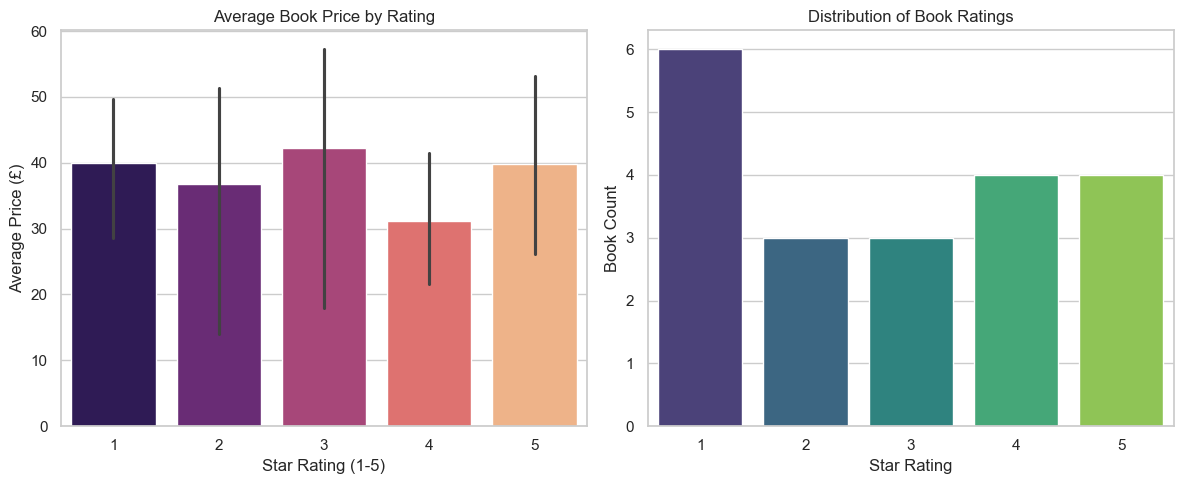

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

url = "http://books.toscrape.com/"
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

books_data = []

books = soup.find_all('article', class_='product_pod')

for book in books:
    title = book.h3.a['title']
    price_str = book.find('p', class_='price_color').text
    
    price = float(price_str.replace('£', '').replace('Â', ''))
    
    rating_class = book.find('p', class_='star-rating')['class'][1]
    rating_dict = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
    rating = rating_dict.get(rating_class, 0)
    
    books_data.append({
        'Title': title,
        'Price_£': price,
        'Rating': rating
    })

df = pd.DataFrame(books_data)

print("--- Scraped Data Summary ---")
print(df.head())

df.to_csv('scraped_books_data.csv', index=False)
print("\n Data successfully saved to 'scraped_books_data.csv'!")

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(data=df, x='Rating', y='Price_£', palette='magma')
plt.title('Average Book Price by Rating')
plt.xlabel('Star Rating (1-5)')
plt.ylabel('Average Price (£)')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Rating', palette='viridis')
plt.title('Distribution of Book Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Book Count')

plt.tight_layout()
plt.show()